# Modelado Predictivo: Holt-Winters
Este notebook entrena un modelo de Suavización Exponencial Triple.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_parquet('../datos/procesados/demanda_top10_series_tiempo.parquet')
# Aislar Upper East Side South
df_zone = df[df['PULocationID'] == 237][['hora', 'total_viajes']].copy()
df_zone.set_index('hora', inplace=True)
df_zone.sort_index(inplace=True)
# Train/Test Split (7 días test)
train_size = len(df_zone) - (7 * 24)
train = df_zone.iloc[:train_size]
test = df_zone.iloc[train_size:]

## Entrenamiento de Holt-Winters

In [3]:
print('Entrenando Holt-Winters...')
modelo_hw = ExponentialSmoothing(train['total_viajes'], seasonal_periods=24, trend='add', seasonal='add')
resultado_hw = modelo_hw.fit()
print('¡Entrenamiento Completado!')

Entrenando Holt-Winters...


c:\Users\User\anaconda3\envs\python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


¡Entrenamiento Completado!


c:\Users\User\anaconda3\envs\python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [4]:
pred_hw = resultado_hw.forecast(len(test))
mae = mean_absolute_error(test['total_viajes'], pred_hw)
rmse = np.sqrt(mean_squared_error(test['total_viajes'], pred_hw))
print(f'MAE Holt-Winters: {mae:.2f}')
print(f'RMSE Holt-Winters: {rmse:.2f}')

MAE Holt-Winters: 85.18
RMSE Holt-Winters: 103.96


## Diagnóstico de Holt-Winters
Veamos visualmente cómo se comporta la línea de predicción exponencial. Su mayor problema suele ser la rigidez cuando se enfrenta a mucha volatilidad diaria continua.

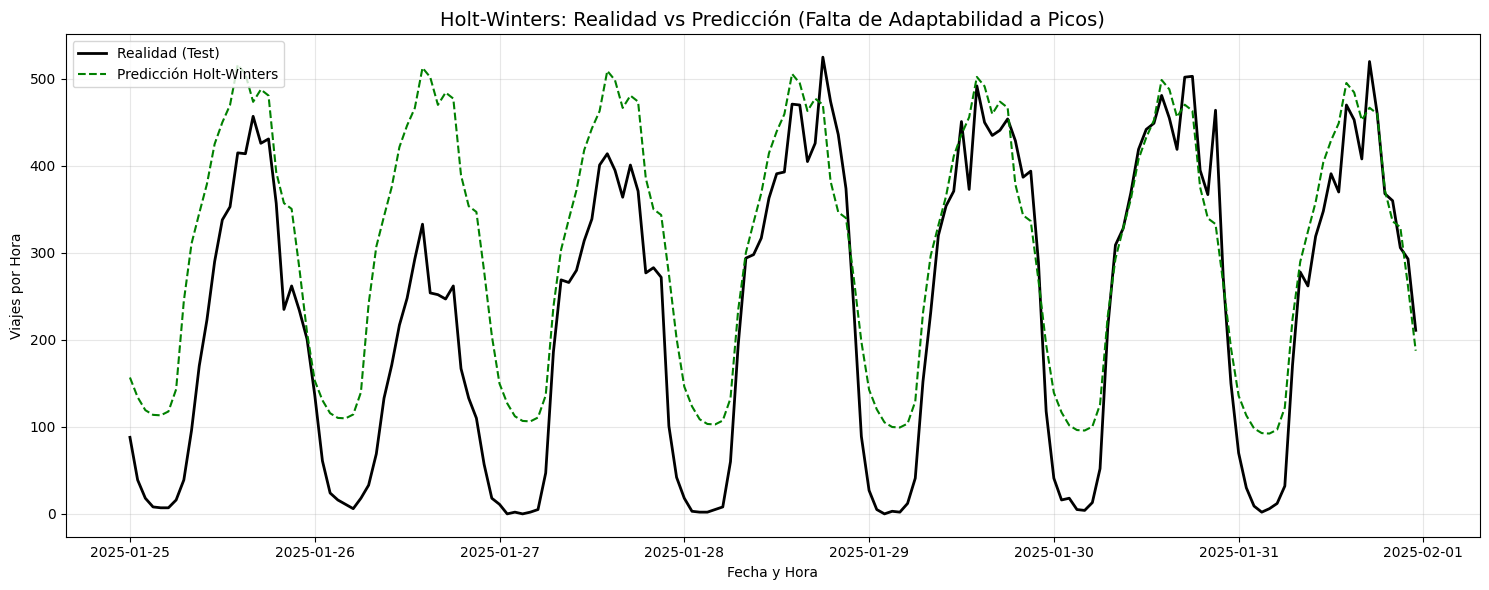

In [5]:
import matplotlib.pyplot as plt

# Gráfico de Predicción vs Realidad
plt.figure(figsize=(15, 6))
plt.plot(test.index, test['total_viajes'], label='Realidad (Test)', color='black', linewidth=2)
plt.plot(test.index, pred_hw, label='Predicción Holt-Winters', color='green', linestyle='--')
plt.title('Holt-Winters: Realidad vs Predicción (Falta de Adaptabilidad a Picos)', fontsize=14)
plt.xlabel('Fecha y Hora')
plt.ylabel('Viajes por Hora')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()